In [4]:
%pip install mlxtend pandas matplotlib seaborn

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pty.py:66: DeprecationWarning: This process (pid=31528) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import urllib.request
import zipfile
import os

In [6]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
file_name = "ml-latest-small.zip"
extract_dir = "ml-latest-small"

print("Завантаження даних...")
if not os.path.exists(extract_dir):
    urllib.request.urlretrieve(url, file_name)
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Архів успішно розпаковано!")
else:
    print("Дані вже існують на диску.")

movies = pd.read_csv(f"{extract_dir}/movies.csv")
ratings = pd.read_csv(f"{extract_dir}/ratings.csv")

df = pd.merge(ratings, movies, on='movieId')

df_liked = df[df['rating'] >= 4.0]

print(f"\nРозмір початкової таблиці об'єднаних даних: {df.shape}")
print(f"Розмір таблиці після фільтрації (тільки оцінки >= 4.0): {df_liked.shape}")
print(f"Кількість унікальних користувачів: {df_liked['userId'].nunique()}")
print(f"Кількість унікальних фільмів, що сподобалися: {df_liked['title'].nunique()}")

df_liked.head()

Завантаження даних...
Дані вже існують на диску.

Розмір початкової таблиці об'єднаних даних: (100836, 6)
Розмір таблиці після фільтрації (тільки оцінки >= 4.0): (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів, що сподобалися: 6297


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [7]:
basket = df_liked.pivot_table(index='userId', 
                              columns='title', 
                              values='rating', 
                              aggfunc='count', 
                              fill_value=0)

basket_sets = (basket > 0).astype(int)

print(f"Форма матриці: {basket_sets.shape}")

basket_sets.iloc[:5, :10]

Форма матриці: (609, 6297)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994)
userId,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0


In [14]:
from mlxtend.frequent_patterns import apriori

thresholds = [0.3, 0.2, 0.1, 0.05]

for i in thresholds:
    frequent_itemsets = apriori(basket_sets, min_support=i, use_colnames=True)

    print(f"При min_suppirts = {i} знайдено наборів: {len(frequent_itemsets)}")

frequent_itemsets_final = apriori(basket_sets, min_support=0.15, use_colnames=True)

frequent_itemsets_final['lenght'] = frequent_itemsets_final['itemsets'].apply(lambda x:len(x))

print("Топ 10 фільмів:")

top_10 = frequent_itemsets_final.sort_values('support', ascending = False).head(10)

top_10


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


При min_suppirts = 0.3 знайдено наборів: 6
При min_suppirts = 0.2 знайдено наборів: 43
При min_suppirts = 0.1 знайдено наборів: 863


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


При min_suppirts = 0.05 знайдено наборів: 33189
Топ 10 фільмів:


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets,lenght
41,0.449918,"frozenset({Shawshank Redemption, The (1994)})",1
15,0.408867,frozenset({Forrest Gump (1994)}),1
35,0.400657,frozenset({Pulp Fiction (1994)}),1
43,0.369458,"frozenset({Silence of the Lambs, The (1991)})",1
30,0.364532,"frozenset({Matrix, The (1999)})",1
45,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...,1
13,0.293924,frozenset({Fight Club (1999)}),1
39,0.287356,frozenset({Schindler's List (1993)}),1
46,0.275862,frozenset({Star Wars: Episode V - The Empire S...,1
69,0.275862,"frozenset({Forrest Gump (1994), Shawshank Rede...",2


In [17]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets_final, metric='lift', min_threshold=1)

top_10_rules = rules.sort_values('lift', ascending=False).head(10)

print("Топ 10 асоціативних правил:")
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Топ 10 асоціативних правил:


,antecedents,consequents,support,confidence,lift
148,frozenset({Lord of the Rings: The Fellowship o...,frozenset({Lord of the Rings: The Return of th...,0.174056,0.946429,4.116964
153,frozenset({Lord of the Rings: The Return of th...,frozenset({Lord of the Rings: The Fellowship o...,0.174056,0.757143,4.116964
152,"frozenset({Lord of the Rings: The Two Towers, ...",frozenset({Lord of the Rings: The Fellowship o...,0.174056,0.809160,4.072551
149,frozenset({Lord of the Rings: The Fellowship o...,"frozenset({Lord of the Rings: The Two Towers, ...",0.174056,0.876033,4.072551
56,"frozenset({Lord of the Rings: The Two Towers, ...",frozenset({Lord of the Rings: The Return of th...,0.192118,0.893130,3.885115
57,frozenset({Lord of the Rings: The Return of th...,"frozenset({Lord of the Rings: The Two Towers, ...",0.192118,0.835714,3.885115
151,frozenset({Lord of the Rings: The Fellowship o...,"frozenset({Lord of the Rings: The Two Towers, ...",0.174056,0.726027,3.779066
150,"frozenset({Lord of the Rings: The Two Towers, ...",frozenset({Lord of the Rings: The Fellowship o...,0.174056,0.905983,3.779066
38,"frozenset({Godfather: Part II, The (1974)})","frozenset({Godfather, The (1972)})",0.167488,0.953271,3.674317
39,"frozenset({Godfather, The (1972)})","frozenset({Godfather: Part II, The (1974)})",0.167488,0.645570,3.674317


Будуємо графік розподілу асоціативних правил...



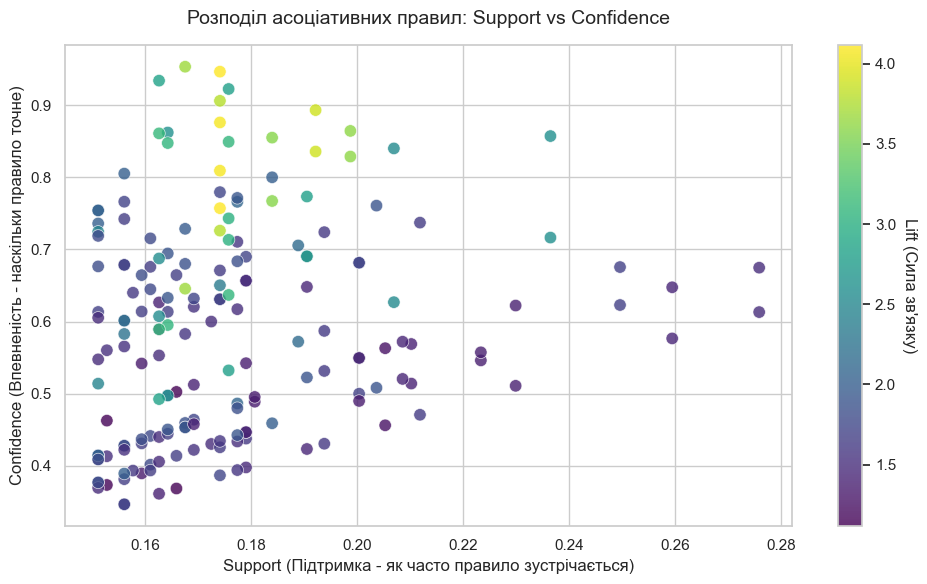

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Будуємо графік розподілу асоціативних правил...\n")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))


scatter = plt.scatter(rules['support'], rules['confidence'], 
                      c=rules['lift'], cmap='viridis', 
                      alpha=0.8, s=80, edgecolors='w', linewidth=0.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Lift (Сила зв\'язку)', rotation=270, labelpad=15)

plt.title('Розподіл асоціативних правил: Support vs Confidence', fontsize=14, pad=15)
plt.xlabel('Support (Підтримка - як часто правило зустрічається)', fontsize=12)
plt.ylabel('Confidence (Впевненість - наскільки правило точне)', fontsize=12)

plt.tight_layout()
plt.show()